# 10 — Advanced EDA Block 6: Geospatial Analysis

**PACE Phase**: Analyze (advanced)
**Objective**: identify geographic crime hotspots in Los Angeles,
measure their persistence over time, and validate them statistically through
spatial autocorrelation indices.

**Input**: `data/processed/crimes_features.parquet`

**Questions we answer**:
- Q6.1 — Hotspot map on a 500m × 500m grid
- Q6.2 — Hotspot persistence over time
- Q6.3 — Statistical spatial clustering (Moran's I, Getis-Ord Gi*)

**Tools used and rationale**:
- **geopandas**: management and manipulation of geospatial data (geometries,
  coordinate systems, spatial operations)
- **folium**: visualization of interactive maps based on Leaflet.js
- **shapely**: creation and manipulation of geometries (points, grids, polygons)
- **PySAL** (in particular the `esda` and `libpysal` modules): the
  reference library for statistical spatial analysis in Python. Used to
  calculate Moran's I (global spatial autocorrelation) and Getis-Ord Gi*
  (identification of local hotspots/coldspots)

**Methodological note**: the LAT/LON coordinates in the dataset are often
obfuscated to the block centroid (~100m precision), as documented
in the project limitations. This should be kept in mind when interpreting
fine-grained results.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import geopandas as gpd
from shapely.geometry import Point, Polygon
import folium

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

df = pd.read_parquet('../../data/processed/crimes_features.parquet')
df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q6.1 — Hotspot map on a 500m × 500m grid

We build a regular grid of 500m × 500m cells over the Los Angeles area
and identify the cells that concentrate the largest share of violent crimes,
despite representing a minimal portion of the total surface area.

**Objective**: identify the zones with the highest concentration of violent
crime at a fine spatial resolution, useful for allocating patrol
resources in a targeted way.

**Preliminary note**: the dataset contains 3,148 records with sentinel
coordinates (0,0) converted to NaN during cleaning. These records
will be excluded from the geospatial analysis.

In [2]:
q61_df = df.loc[df['crime_category'] == 'person', ['LAT', 'LON', 'month', 'year']].copy()

print(q61_df.head())

       LAT       LON  month  year
0  33.9825 -118.2695      2  2010
3  34.1016 -118.3295      1  2010
4  34.0387 -118.2488      1  2010
7  34.0435 -118.2427      1  2010
8  34.0450 -118.2640      1  2010


In [3]:
print(q61_df.isna().sum())
print(q61_df.shape)

LAT      1362
LON      1362
month       0
year        0
dtype: int64
(1093024, 4)


In [4]:
q61_df = q61_df.dropna()
print(q61_df.shape)

(1091662, 4)


In [5]:
geometry = gpd.points_from_xy(q61_df['LON'], q61_df['LAT'])
q61_gdf = gpd.GeoDataFrame(q61_df, geometry=geometry, crs='EPSG:4326')
print(q61_gdf.head())

       LAT       LON  month  year                   geometry
0  33.9825 -118.2695      2  2010  POINT (-118.2695 33.9825)
3  34.1016 -118.3295      1  2010  POINT (-118.3295 34.1016)
4  34.0387 -118.2488      1  2010  POINT (-118.2488 34.0387)
7  34.0435 -118.2427      1  2010  POINT (-118.2427 34.0435)
8  34.0450 -118.2640      1  2010    POINT (-118.264 34.045)


In [6]:
q61_gdf = q61_gdf.to_crs('EPSG:32611')
print(q61_gdf.head())
print(q61_gdf.total_bounds)

       LAT       LON  month  year                        geometry
0  33.9825 -118.2695      2  2010  POINT (382736.762 3760941.804)
3  34.1016 -118.3295      1  2010  POINT (377365.803 3774219.079)
4  34.0387 -118.2488      1  2010  POINT (384724.916 3767150.226)
7  34.0435 -118.2427      1  2010  POINT (385294.495 3767675.637)
8  34.0450 -118.2640      1  2010  POINT (383330.367 3767866.052)
[ 337119.687848   3690064.40020423  434393.29978211 3850623.09029826]


In [7]:
minx, miny, maxx, maxy = q61_gdf.total_bounds
print(minx, miny, maxx, maxy)

cell_size = 500  # meters

n_cols = int((maxx - minx) / cell_size) + 1
n_rows = int((maxy - miny) / cell_size) + 1

print(f'Columns: {n_cols}, Rows: {n_rows}, Total cells: {n_cols * n_rows}')

337119.68784799986 3690064.4002042282 434393.2997821095 3850623.090298263
Colonne: 195, Righe: 322, Totale celle: 62790


In [8]:
from shapely.geometry import box

grid_cells = []
for i in range(n_cols):
    for j in range(n_rows):
        x0 = minx + i * cell_size
        y0 = miny + j * cell_size
        x1 = x0 + cell_size
        y1 = y0 + cell_size
        grid_cells.append(box(x0, y0, x1, y1))

print(f'Cells created: {len(grid_cells)}')

Celle create: 62790


In [9]:
grid_gdf = gpd.GeoDataFrame({'geometry': grid_cells}, crs='EPSG:32611')
grid_gdf['cell_id'] = grid_gdf.index
print(grid_gdf.head())

                                            geometry  cell_id
0  POLYGON ((337619.688 3690064.4, 337619.688 369...        0
1  POLYGON ((337619.688 3690564.4, 337619.688 369...        1
2  POLYGON ((337619.688 3691064.4, 337619.688 369...        2
3  POLYGON ((337619.688 3691564.4, 337619.688 369...        3
4  POLYGON ((337619.688 3692064.4, 337619.688 369...        4


In [10]:
joined = gpd.sjoin(q61_gdf, grid_gdf, how='left', predicate='within')
print(joined.head())
print(joined.shape)

       LAT       LON  month  year                        geometry  \
0  33.9825 -118.2695      2  2010  POINT (382736.762 3760941.804)   
3  34.1016 -118.3295      1  2010  POINT (377365.803 3774219.079)   
4  34.0387 -118.2488      1  2010  POINT (384724.916 3767150.226)   
7  34.0435 -118.2427      1  2010  POINT (385294.495 3767675.637)   
8  34.0450 -118.2640      1  2010  POINT (383330.367 3767866.052)   

   index_right  cell_id  
0      29443.0  29443.0  
3      25928.0  25928.0  
4      30744.0  30744.0  
7      31067.0  31067.0  
8      29779.0  29779.0  
(1091662, 7)


In [11]:
cell_counts = joined.groupby('cell_id', as_index=False).size()
cell_counts.columns = ['cell_id', 'crime_count']
cell_counts = cell_counts.sort_values('crime_count', ascending=False)
print(cell_counts.head(10))
print(f'\nCells with at least 1 crime: {len(cell_counts)}')
print(f'Total cells in the grid: {len(grid_gdf)}')

      cell_id  crime_count
4178  30745.0         9017
3874  29138.0         5888
4129  30423.0         5265
4224  31067.0         4930
4177  30744.0         4922
2983  25284.0         4268
4080  30102.0         3811
3039  25606.0         3642
4179  30746.0         3461
4130  30424.0         3302

Celle con almeno 1 crimine: 4706
Celle totali nella griglia: 62790


In [12]:
total_crimes = cell_counts['crime_count'].sum()
total_active_cells = len(cell_counts)

cell_counts['cumulative_pct'] = cell_counts['crime_count'].cumsum() / total_crimes * 100
cell_counts['cell_rank_pct'] = (range(1, len(cell_counts) + 1))
cell_counts['cell_rank_pct'] = cell_counts['cell_rank_pct'] / total_active_cells * 100

top5pct_cells = cell_counts[cell_counts['cell_rank_pct'] <= 5]
print(f'Cells in the top 5%: {len(top5pct_cells)}')
print(f'Crimes in those cells: {top5pct_cells["crime_count"].sum()}')
print(f'Percentage of crimes covered: {top5pct_cells["crime_count"].sum() / total_crimes * 100:.1f}%')

Celle nel top 5%: 235
Crimini in quelle celle: 359163
Percentuale crimini coperta: 32.9%


In [13]:
top5pct_geo = grid_gdf[grid_gdf['cell_id'].isin(top5pct_cells['cell_id'])].copy()
top5pct_geo = top5pct_geo.to_crs('EPSG:4326')

m = folium.Map(location=[34.05, -118.25], zoom_start=10, tiles='CartoDB positron')

for _, row in top5pct_geo.iterrows():
    folium.GeoJson(
        row['geometry'],
        style_function=lambda x: {'fillColor': 'red', 'color': 'red', 'weight': 1, 'fillOpacity': 0.5}
    ).add_to(m)

m

m.save('../../outputs/10_advanced_eda_block1/32_hotspot_map_top5pct.html')

## 3. Q6.2 — Hotspot persistence over time

We measure hotspot stability by calculating the degree of overlap
between hotspots identified in consecutive time periods.

**Objective**: distinguish between:
- **Chronic hotspots**: cells that remain consistently among the hottest
  over time — require long-term structural interventions
- **Emerging hotspots**: cells that become hot only in certain periods —
  require tactical, reactive interventions

**Metric**: month-over-month overlap percentage — how many of the current
month's hotspot cells were already hotspots the previous month.

In [14]:
monthly_counts = (
    joined
    .groupby(['year', 'month', 'cell_id'], as_index=False)
    .size()
    .rename(columns={'size': 'crime_count'})
)
print(monthly_counts.head(10))
print(f'Shape: {monthly_counts.shape}')

   year  month  cell_id  crime_count
0  2010      1   6633.0            1
1  2010      1   6949.0            1
2  2010      1   6950.0            1
3  2010      1   6958.0            3
4  2010      1   7267.0            1
5  2010      1   7269.0            1
6  2010      1   7273.0            1
7  2010      1   7590.0            1
8  2010      1   7593.0            1
9  2010      1   7594.0            2
Shape: (343129, 4)


In [15]:
def get_hotspot_cells(group, pct=0.05):
    n = max(1, int(len(group) * pct))
    return set(group.nlargest(n, 'crime_count')['cell_id'])

monthly_hotspots = (
    monthly_counts
    .groupby(['year', 'month'])
    .apply(get_hotspot_cells, include_groups=False)
    .reset_index()
)
monthly_hotspots.columns = ['year', 'month', 'hotspot_cells']
print(monthly_hotspots.head(5))
print(f'Total months: {len(monthly_hotspots)}')

   year  month                                      hotspot_cells
0  2010      1  {30720.0, 28160.0, 25603.0, 30723.0, 25606.0, ...
1  2010      2  {25604.0, 28170.0, 28172.0, 28175.0, 28179.0, ...
2  2010      3  {28160.0, 30722.0, 25603.0, 25606.0, 28172.0, ...
3  2010      4  {30720.0, 25603.0, 25606.0, 28170.0, 28171.0, ...
4  2010      5  {30720.0, 28160.0, 28161.0, 28170.0, 28173.0, ...
Mesi totali: 180


In [16]:
overlaps = []
for i in range(1, len(monthly_hotspots)):
    current = monthly_hotspots.iloc[i]['hotspot_cells']
    previous = monthly_hotspots.iloc[i-1]['hotspot_cells']
    overlap_pct = len(current & previous) / len(current) * 100
    overlaps.append({
        'year': monthly_hotspots.iloc[i]['year'],
        'month': monthly_hotspots.iloc[i]['month'],
        'overlap_pct': overlap_pct
    })

overlap_df = pd.DataFrame(overlaps)
print(overlap_df.head(10))
print(f'\nAverage overlap: {overlap_df["overlap_pct"].mean():.1f}%')

   year  month  overlap_pct
0  2010      2    48.000000
1  2010      3    45.192308
2  2010      4    51.000000
3  2010      5    46.226415
4  2010      6    49.074074
5  2010      7    50.476190
6  2010      8    48.076923
7  2010      9    39.603960
8  2010     10    46.601942
9  2010     11    54.639175

Overlap medio: 49.4%


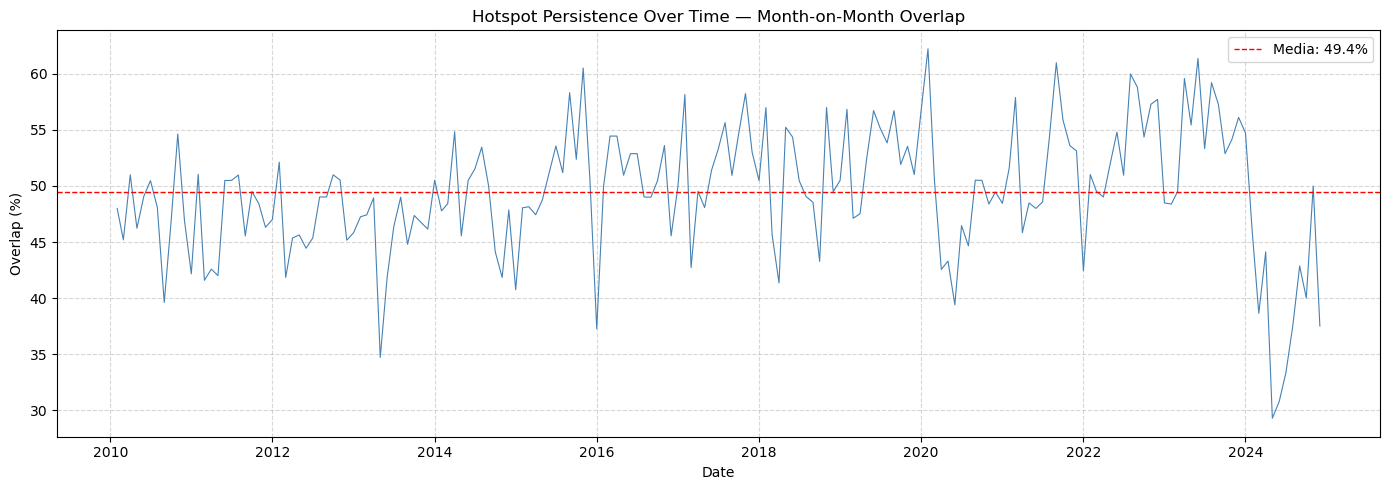

In [17]:
overlap_df['date'] = pd.to_datetime(overlap_df[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(overlap_df['date'], overlap_df['overlap_pct'], linewidth=0.8, color='steelblue')
ax.axhline(y=overlap_df['overlap_pct'].mean(), color='red', linestyle='--', linewidth=1, label=f'Average: {overlap_df["overlap_pct"].mean():.1f}%')
ax.set_title('Hotspot Persistence Over Time — Month-on-Month Overlap')
ax.set_xlabel('Date')
ax.set_ylabel('Overlap (%)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../../outputs/10_advanced_eda_block1/33_hotspot_persistence.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations Q6.2 — Hotspot persistence over time

**Metric**: month-over-month overlap percentage — how many hot cells of the
current month were already hot the previous month.

**Average overlap: 49.4%** — about half of each month's hot cells
were already hot the previous month. This indicates that hotspots have
a significant but not dominant chronic component: they don't change
completely from one month to the next, but about 50% of hotspots
turn over every month.

**Temporal pattern — two distinct phases**:

- **2010–2015**: volatile overlap, frequently below average.
  Hotspots change more month to month, suggesting crime that is
  more dynamic and less geographically rooted. Exception: the
  2015 period shows a peak above average, consistent with the LAPD
  classification anomaly already documented in previous blocks.

- **2016–2023**: trend reversal. Overlap stabilizes and stays
  more frequently above the overall average. Hotspots become more
  chronic and persistent — the same areas tend to stay hot month
  after month with greater regularity.

**2024**: a drop in overlap, consistent with the incomplete data already
documented in all previous blocks. It should not be interpreted as
a real change in the distribution of hotspots.

**Operational implication**: an average overlap of 49% suggests that
both types of intervention are needed:
- **Structural**: for chronically hot cells that persist over time
- **Tactical and reactive**: for cells that emerge and disappear month to month

## 4. Q6.3 — Statistical spatial clustering (Moran's I and Getis-Ord Gi*)

We apply spatial autocorrelation indices to statistically validate
the clusters identified in Q6.1 and identify significant hotspots and
coldspots.

**Tools**:
- **Moran's I** (`esda` module from PySAL): global index measuring whether
  the spatial distribution of crimes is random or clustered
- **Getis-Ord Gi*** (`esda` module from PySAL): local index producing
  a score for each cell, identifying statistically significant
  hotspots and coldspots

**Moran's I interpretation**:
- Value close to +1: crimes are concentrated in clusters
- Value close to 0: random distribution
- Value close to -1: dispersed distribution

**Getis-Ord Gi* interpretation**:
- High positive Z-score: hotspot (hot area surrounded by hot areas)
- High negative Z-score: coldspot (cold area surrounded by cold areas)
- Z-score close to 0: no significant spatial pattern

In [18]:
from libpysal.weights import Queen
from esda.moran import Moran
from esda.getisord import G_Local

grid_with_counts = grid_gdf.merge(cell_counts, on='cell_id', how='left')
grid_with_counts['crime_count'] = grid_with_counts['crime_count'].fillna(0)
print(grid_with_counts.head())
print(f'Shape: {grid_with_counts.shape}')

                                            geometry  cell_id  crime_count  \
0  POLYGON ((337619.688 3690064.4, 337619.688 369...        0          0.0   
1  POLYGON ((337619.688 3690564.4, 337619.688 369...        1          0.0   
2  POLYGON ((337619.688 3691064.4, 337619.688 369...        2          0.0   
3  POLYGON ((337619.688 3691564.4, 337619.688 369...        3          0.0   
4  POLYGON ((337619.688 3692064.4, 337619.688 369...        4          0.0   

   cumulative_pct  cell_rank_pct  
0             NaN            NaN  
1             NaN            NaN  
2             NaN            NaN  
3             NaN            NaN  
4             NaN            NaN  
Shape: (62790, 5)


In [19]:
grid_with_counts = grid_with_counts[['geometry', 'cell_id', 'crime_count']].copy()
print(grid_with_counts['crime_count'].describe())

count    62790.000000
mean        17.385778
std        127.476057
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       9017.000000
Name: crime_count, dtype: float64


In [21]:
w = Queen.from_dataframe(grid_with_counts, silence_warnings=True, use_index=True)
print(f'Number of cells: {w.n}')
print(f'Average neighbors per cell: {w.mean_neighbors:.2f}')

Numero di celle: 62790
Media vicini per cella: 7.95


In [22]:
moran = Moran(grid_with_counts['crime_count'], w)
print(f'Moran\'s I: {moran.I:.4f}')
print(f'p-value: {moran.p_sim:.4f}')
print(f'z-score: {moran.z_sim:.4f}')

Moran's I: 0.7359
p-value: 0.0010
z-score: 376.8214


In [24]:
gi = G_Local(grid_with_counts['crime_count'], w, star=None, permutations=999)
grid_with_counts['gi_zscore'] = gi.Zs
grid_with_counts['gi_pvalue'] = gi.p_sim
print(grid_with_counts[['cell_id', 'crime_count', 'gi_zscore', 'gi_pvalue']].describe())

            cell_id   crime_count     gi_zscore     gi_pvalue
count  62790.000000  62790.000000  62790.000000  62790.000000
mean   31394.500000     17.385778      0.000090      0.017841
std    18126.056038    127.476057      0.842079      0.071510
min        0.000000      0.000000     -0.136387      0.001000
25%    15697.250000      0.000000     -0.136387      0.001000
50%    31394.500000      0.000000     -0.136387      0.001000
75%    47091.750000      0.000000     -0.136387      0.001000
max    62789.000000   9017.000000     29.225619      0.447000


In [25]:
grid_with_counts['hotspot_type'] = 'Not Significant'
grid_with_counts.loc[
    (grid_with_counts['gi_zscore'] > 1.96) & (grid_with_counts['gi_pvalue'] <= 0.05),
    'hotspot_type'] = 'Hot Spot (95%)'
grid_with_counts.loc[
    (grid_with_counts['gi_zscore'] > 2.58) & (grid_with_counts['gi_pvalue'] <= 0.01),
    'hotspot_type'] = 'Hot Spot (99%)'
grid_with_counts.loc[
    (grid_with_counts['gi_zscore'] < -1.96) & (grid_with_counts['gi_pvalue'] <= 0.05),
    'hotspot_type'] = 'Cold Spot (95%)'

print(grid_with_counts['hotspot_type'].value_counts())

hotspot_type
Not Significant    61597
Hot Spot (99%)       908
Hot Spot (95%)       285
Name: count, dtype: int64


In [26]:
grid_geo = grid_with_counts.to_crs('EPSG:4326')

color_map = {
    'Hot Spot (99%)': 'darkred',
    'Hot Spot (95%)': 'red',
    'Not Significant': None
}

m2 = folium.Map(location=[34.05, -118.25], zoom_start=10, tiles='CartoDB positron')

for _, row in grid_geo[grid_geo['hotspot_type'] != 'Not Significant'].iterrows():
    folium.GeoJson(
        row['geometry'],
        style_function=lambda x, color=color_map[row['hotspot_type']]: {
            'fillColor': color,
            'color': color,
            'weight': 0.5,
            'fillOpacity': 0.6
        }
    ).add_to(m2)

m2.save('../../outputs/10_advanced_eda_block1/34_getisord_hotspots.html')
m2

### Observations Q6.3 — Statistical spatial clustering (Moran's I and Getis-Ord Gi*)

**Note**: the entire geospatial analysis (Q6.1, Q6.2, Q6.3) is based
exclusively on crimes with `crime_category == 'person'`
(1,091,662 records with valid coordinates out of 1,093,024 total).
Crimes against property and the "Other" category are excluded.

**Global Moran's I**:
- **I = 0.7359** — high positive value, confirming strong spatial clustering
- **p-value = 0.001** — statistically significant at 99.9%
- **z-score = 376.82** — the observed clustering is 376 standard deviations
  above what would be expected by chance

Moran's I confirms with very high statistical certainty that crimes
against the person in Los Angeles are not randomly distributed in
space but concentrate in real geographic clusters.

**Getis-Ord Gi* — hotspot distribution**:
- **908 Hot Spot cells at 99%**: statistically significant clusters
  with very high confidence
- **285 Hot Spot cells at 95%**: significant clusters with slightly
  lower confidence
- **No significant Cold Spots**: empty cells are so numerous that they
  don't generate statistically relevant cold clusters
- **61,597 Not Significant cells**: the vast majority of the grid
  is neutral

**Geographic distribution of hotspots**:
- **Main cluster** (dark red, 99%): the largest and most compact,
  covering Downtown LA and South LA up to Inglewood. This is the
  statistically most robust cluster and corresponds to the areas already
  identified in previous blocks (77th Street, Southeast, Southwest).
- **North cluster** (North Hollywood/Van Nuys): second significant
  cluster, more fragmented.
- **Long Beach cluster**: isolated hotspot in the southern part of the map.
- **Coastal cluster**: small hotspots scattered around the
  Santa Monica/Venice area.

**Comparison with Q6.1**: the Q6.1 map colored the hottest cells in
absolute terms, including potential random anomalies. The Getis-Ord map
shows only statistically validated cells — the main cluster
remains the same but with a solid statistical basis that makes it
defensible in the final report.

**Consistency with previous blocks**: the identified clusters
geographically correspond to the areas that dominated domestic
crimes (Block 3) and firearm crimes (Block 4),
confirming the structural concentration of crime in
specific areas of Los Angeles.